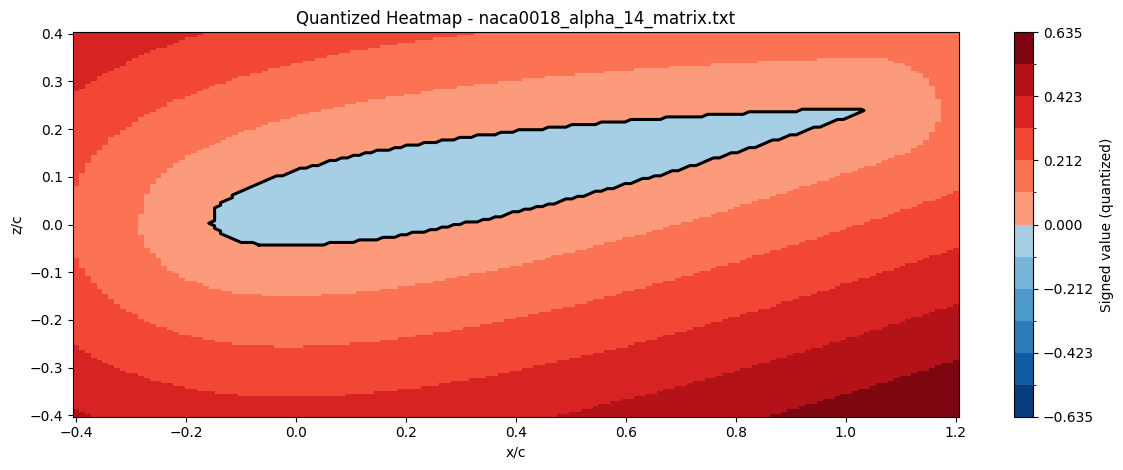

<Figure size 640x480 with 0 Axes>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from pathlib import Path


def load_numeric_file(path):
    path = Path(path)
    data = np.genfromtxt(path, comments="#", autostrip=True, invalid_raise=False)

    if data.ndim == 1:
        data = data.reshape(-1, 1)

    if data.ndim == 2:
        data = data[~np.all(np.isnan(data), axis=1)]

    if data.size == 0:
        raise ValueError(f"No numeric data found in {path.name}")

    return data


def _longest_closed_segment(segments, tol=0.02):
    if not segments:
        return None

    def arc_len(seg):
        d = np.diff(seg, axis=0)
        return np.sum(np.hypot(d[:, 0], d[:, 1]))

    closed = [s for s in segments if np.hypot(*(s[0] - s[-1])) < tol]
    candidates = closed if closed else segments
    return max(candidates, key=arc_len)


def _draw_main_boundary(X, Z, data, linewidth=2.2):
    inside = (data < 0.0).astype(float)
    cs = plt.contour(X, Z, inside, levels=[0.5], colors="none")
    seg = _longest_closed_segment(cs.allsegs[0])
    if seg is not None:
        plt.plot(seg[:, 0], seg[:, 1], color="black", linewidth=linewidth)


def _build_quantized_diverging_cmap(n_bins_per_side=6):
    # Negative: dark blue (large magnitude) -> light blue (near zero).
    neg = plt.cm.Blues(np.linspace(0.95, 0.35, n_bins_per_side))
    # Positive: light red (near zero) -> dark red (large magnitude).
    pos = plt.cm.Reds(np.linspace(0.35, 0.95, n_bins_per_side))
    return ListedColormap(np.vstack([neg, pos]))


def plot_quantized_signed_heatmap(data, title, x_label="x/c", z_label="z/c", n_bins_per_side=6):
    """Quantized signed heatmap: faint near zero, bold at larger magnitudes."""
    nz, nx = data.shape

    x = np.linspace(-0.4, 1.2, nx)
    z = np.linspace(-0.4, 0.4, nz)
    X, Z = np.meshgrid(x, z)

    finite = np.isfinite(data)
    if not np.any(finite):
        raise ValueError("Data contains no finite values.")

    max_abs = np.nanmax(np.abs(data))
    if np.isclose(max_abs, 0.0):
        max_abs = 1.0

    # Symmetric bin boundaries around zero for balanced blue/red quantization.
    boundaries = np.linspace(-max_abs, max_abs, 2 * n_bins_per_side + 1)
    cmap = _build_quantized_diverging_cmap(n_bins_per_side=n_bins_per_side)
    norm = BoundaryNorm(boundaries, ncolors=cmap.N, clip=True)

    plt.figure(figsize=(12, 4.8))
    mesh = plt.pcolormesh(X, Z, data, cmap=cmap, norm=norm, shading="auto")

    if np.nanmin(data) < 0.0 < np.nanmax(data):
        _draw_main_boundary(X, Z, data, linewidth=2.2)

    cbar = plt.colorbar(mesh, boundaries=boundaries, spacing="proportional")
    cbar.set_label("Signed value (quantized)")

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(z_label)
    plt.tight_layout()
    plt.show()
    plt.savefig("SDF.png", dpi=30)


sdf_file = Path("data/naca0018_alpha_14_matrix.txt")
sdf_matrix = load_numeric_file(sdf_file)
plot_quantized_signed_heatmap(sdf_matrix, f"Quantized Heatmap - {sdf_file.name}")
